<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_8_Inpainting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook Setup
--------------

In [6]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt

Define the root folder for the project

In [7]:
ROOT_FOLDER = './data'

Useful function for plot a 2D dictionary

In [41]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements OMP

In [42]:
def OMP(s, D, L, tau):
    """
    Orthogonal Matching Pursuit (OMP) algorithm.

    Finds a sparse representation of a signal `s` with respect to a redundant 
    dictionary `D`.

    Parameters
    ----------
    D : numpy.ndarray
        A 2D array of shape (M, N) representing the redundant dictionary matrix.
    s : numpy.ndarray
        A 1D array of shape (M,) representing the signal vector.
    L : int
        The sparsity level. 
    tau : float, optional
        The stopping threshold for the residual norm (default is 0.1).

    Returns
    -------
    x : numpy.ndarray
        A 1D array of shape (N,) containing the computed sparse code.

    Raises
    ------
    RuntimeError
        If a linear algebra error occurs during the update step.
    """

    # Input validation
    if not isinstance(D, np.ndarray) or not isinstance(s, np.ndarray):
        raise TypeError("D and s must be numpy arrays!")
    if D.ndim != 2 or s.ndim != 1:
        raise ValueError(
            f"Expected D to be 2D and s to be 1D, got {D.ndim}D and {s.ndim}D.")
    if D.shape[0] != s.shape[0]:
        raise ValueError(
            f"Dimension mismatch: D rows ({D.shape[0]}) != s length ({s.shape[0]}).")
    if not isinstance(L, int) or L <= 0:
        raise ValueError("The sparsity level L must be a positive integer!")
    if tau < 0:
        raise ValueError("The threshold must be positive!")

    _, N = D.shape
    x = np.zeros(N)
    r = s.copy()                    # Residual vector
    omega = []                      # Support set
    res_norm = np.linalg.norm(r)

    while res_norm > tau and np.count_nonzero(x) < L:
        # Sweep step
        e = np.zeros(N)
        for j in range(N):
            e[j] = res_norm ** 2 - (np.dot(r, D[:, j])) ** 2

        j_star = int(np.argmin(e))

        omega.append(j_star)                 # update the support set

        # Update step
        D_w = D[:, omega]

        try:
            x_w = np.linalg.solve(D_w.T @ D_w, D_w.T @ s)
        except np.linalg.LinAlgError as ex:
            raise RuntimeError(
                "Linear algebra error during update step. The matrix D_w.T @ D_w might be singular.") from ex

        x = np.zeros(N)
        x[omega] = x_w                      # update the solution
        r = s - D_w @ x_w                   # update the residual
        res_norm = np.linalg.norm(r)        # compute residual norm

    return x

Load the image and rescale it in $[0,1]$

In [43]:
img = imread(f'{ROOT_FOLDER}/peppers256.png') / 255
# Alternatively, '{ROOT_FOLDER}/Lena512.png' or '{ROOT_FOLDER}/babara.png' 

imsz = img.shape
p = 8               # patch size
M = p ** 2          # no. of elements in the patch

Corrupt the image with white gaussian noise

In [44]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(0, sigma_noise, size=imsz)

Percentage of removed pixel

In [45]:
perc_of_removed_pixels = 0.25

Arbitrarily remove pixels setting them to zero and compute PSNR of the noisy input before inpainting

In [46]:
# Create a vector, idx, with all the indexes of the image
idx = np.arange(imsz[0]*imsz[1])

# Shuffle it and take the target percentage of indexes
rng = np.random.default_rng()
rng.shuffle(idx)
idx = idx[:int(imsz[0]*imsz[1]*perc_of_removed_pixels)]

# msk is 0 for the chosen idx, 1 elsewhere
msk = np.ones(imsz).flatten()
msk[idx] = 0
msk = msk.reshape(imsz)

# Compute PSNR before masking
psnr_noisy = 10 * np.log10(1/np.mean(np.square(noisy_img - img)))

# Apply the mask
noisy_img = noisy_img * msk

Text(0.5, 1.0, 'Dead pixels')

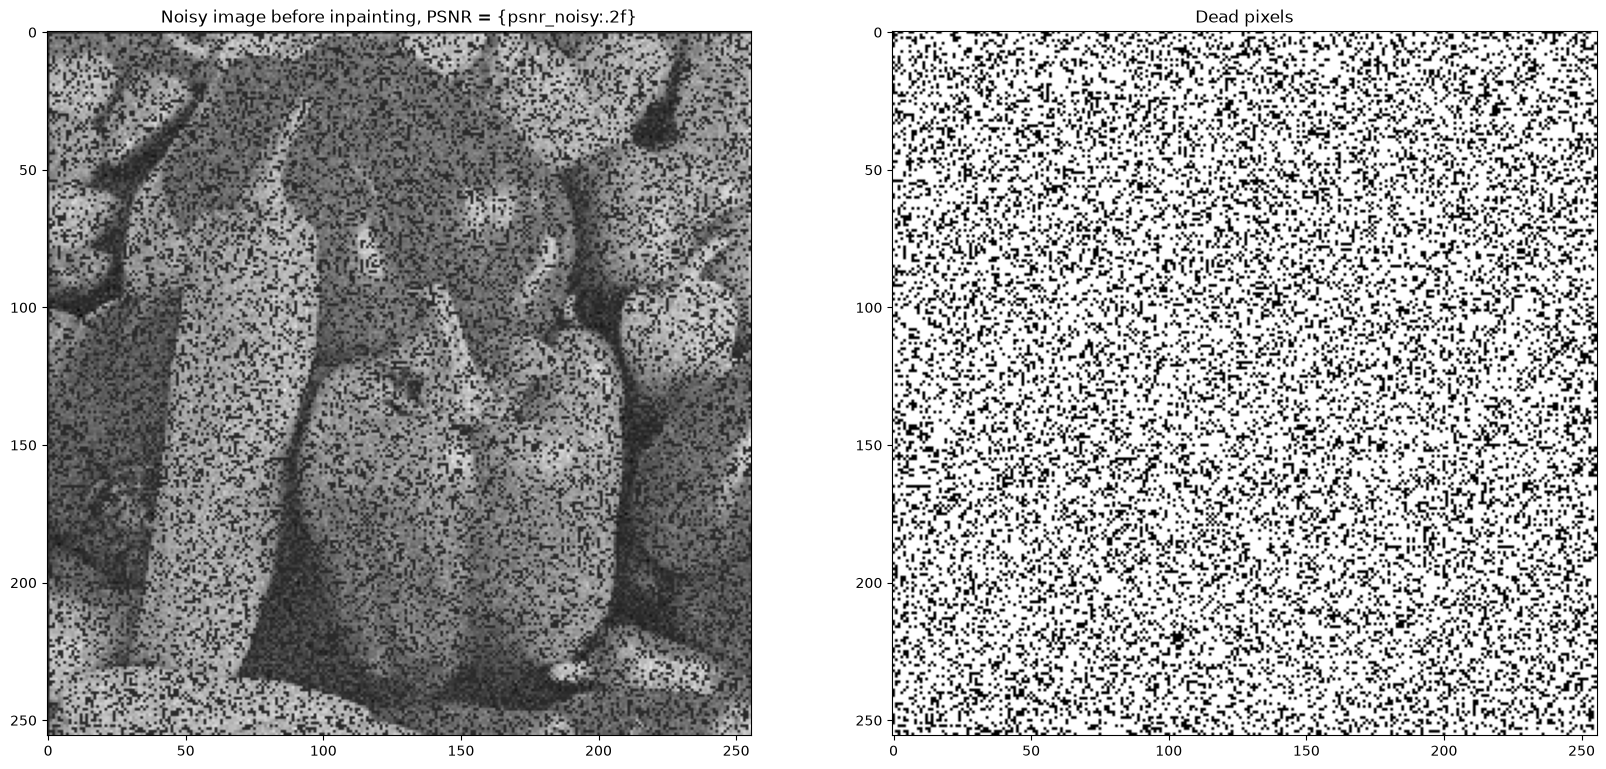

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(noisy_img, cmap='gray')
ax[0].set_title(f'Noisy image before inpainting, PSNR = {psnr_noisy:.2f}')

ax[1].imshow(msk, cmap='gray')
ax[1].set_title('Dead pixels')

Load and display the dictionary learned from patches

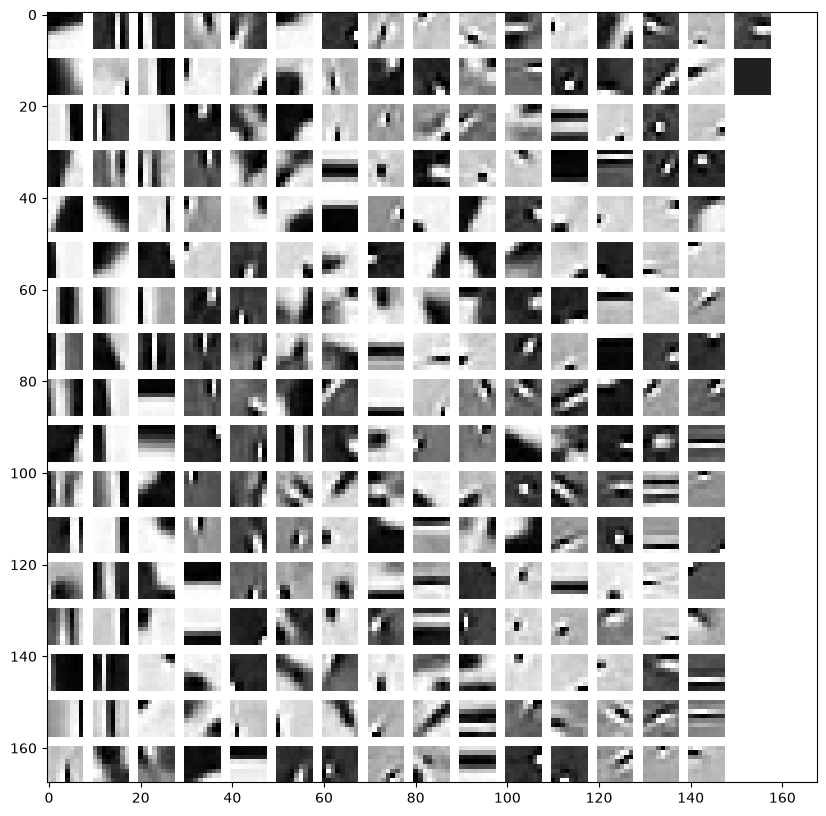

In [48]:
D = loadmat(f'{ROOT_FOLDER}/dict_nat_img.mat')['D']

# Add a constant atom to D and normalize it
new_atom = np.ones((M, 1))
new_atom /= np.linalg.norm(new_atom)
D = np.hstack([D, new_atom])

# Display the dictionary
D_img = get_dictionary_img(D)

plt.figure(figsize=(10, 10))
plt.imshow(D_img, cmap='gray')

Inpainting
----------


In [49]:
# Stopping criteria of OMP (related to sparsity level and errors)
L = M // 2

# Initialize the estimated image
img_hat = np.zeros_like(img)

# Initialize the weight matrix
weights = np.zeros_like(img)

# Define the step
STEP = 4                        # = p for non overlapping paches

Operate patchwise

In [50]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # Extrach the patch with the top left corner at pixel (i, j)
        s = noisy_img[i:i + p, j: j + p].flatten()

        # Extract the correspondet patch from the mask
        m = msk[i:i + p, j:j + p].flatten()

        # Design the projection operator over the current patch
        P = np.diag(m)

        tau = 1.15 * sigma_noise * np.sqrt(
            # proportional to the no. of pixels remaining in
            np.count_nonzero(m))
        # the patch

        # Sparse coding w.r.t. the inpainted dictionary
        x = OMP(s, P @ D, L, tau)

        # Synthesis w.r.t. D, the dictionary yielding sparse representation
        s_hat = D @ x

        w = 1

        # Put the denoised patch into the estimated image using uniform weights
        img_hat[i:i+p, j:j+p] += w * s_hat.reshape((p, p))

        # Store the weight of the current patch in the weight matrix
        weights[i:i+p, j:j+p] += w

Normalize the estimated image with the computed weights

In [51]:
img_hat = img_hat / weights

Compute the PSNR of the estimated image

In [52]:
psnr_hat = 10 * np.log10(1 / np.mean((img - img_hat) ** 2))

Text(0.5, 1.0, 'Estimated Image \nPSNR = 27.95')

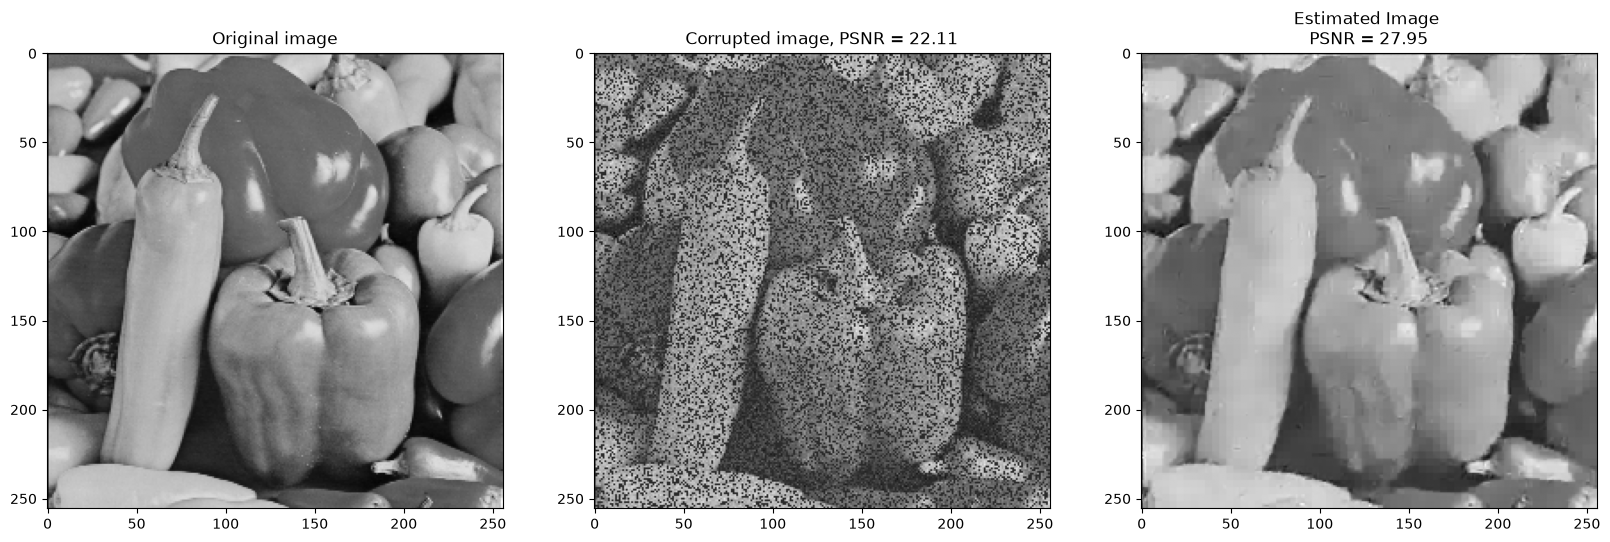

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Corrupted image, PSNR = {psnr_noisy:.2f}')

ax[2].imshow(img_hat, cmap='gray')
ax[2].set_title(f'Estimated Image \nPSNR = {psnr_hat:.2f}')